In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# Introduction

Today, in modern supply chains, sophisticated systems generate forecasts and allocation proposals. However, human planners often review and adjust these recommendations. The critical question for supply chain leaders is not just "How accurate are our forecasts?" but "Are these manual interventions actually adding value, or are they introducing noise and cost?"

This article introduces two powerful audit tools:

* **Forecast Value Added (FVA)**: Evaluates whether human adjustments improve demand forecasts.

* **Allocation Value Added (AVA)**: Uses the same FVA approach to assess whether human adjustments to inventory allocation proposals lead to better distribution outcomes,regarding stockouts and overstocks.

By using both FVA and AVA, organizations can objectively measure the contribution of each planning and execution step, optimize processes, and ensure resources are focused where they truly add value.

***Important Note:*** I've not found a standard name for this latter methodology. It can be symply addressed as FVA or you can find it called also Inventory Optimization Analysis, Inventory Value Added (acronym too similar to IVA, the Italian value added taxes 😭), Inventory Value Added Analysis. My intention was to keep the two process separated.

# What is Forecast Value Added (FVA)?

Forecast Value Added (FVA) is a management technique used to assess the effectiveness and efficiency of a demand planning process. It measures what incremental value each step or functional team adds to the forecast's accuracy. FVA is an internal audit tool that identifies and helps eliminate non-value-added work.

### Why FVA Matters to Supply Chain Professionals?

Many organizations spend time and resources adjusting automated forecasts. If these manual adjustments consistently make the forecast worse, they introduce costs without benefit. FVA provides the following outcomes:

* Quantify Functional Contribution: measure the value added by different teams (Sales, Planning, Marketing).

* Identify Waste: detect non-value-added steps and remove them, freeing up planner time.

### Establishing the Baseline:

The **Baseline Forecast** is the starting point against which all subsequent forecast versions are measured. The most common baseline is the output from a fully Automated Model (Statistical, ML).
It represents the accuracy that can be achieved without any human intervention. Every subsequent forecast adjustment must be able to beat this baseline to be considered valuable. In Sales & Operations Planning (S&OP), for example, the forecast moves sequentially through different hands in order to achieve a consensus plan. We must measure the incremental value added by each function.

### The FVA Metric:

FVA is expressed as a percentage representing the reduction in error achieved by the intervention step. In this demostration we'll use Mean Absolute Percent Error (MAPE). The formula for the value added by a specific Step n is:

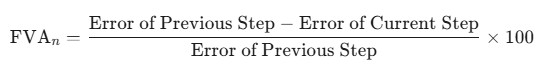

* **FVA >0%**: Value Added. The step improves accuracy.
* **FVA <0%**: Value Destroyed. The step made the forecast worse.


**Advice**: It is also always good practice to measure bias as an error metric, alongside commonly used metrics like MAPE, Root Mean Square Error (RMSE), or Weighted Mean Absolute Percent Error (WMAPE). Bias provides essential insight into the systematic direction of the error (consistent over- or under-forecasting).

Furthermore, it is useful to evaluate an error concept that is more directly linked to financial results (such as utilizing penalty costs for stockouts or overstocks). We will explore this crucial concept of a financialized error metric, including penalty systems, in the subsequent Allocation Value Added (AVA) section and in future articles.

### FVA Data and Scenario Description

We analyze the sequential contributions of the Demand Planner and the Sales team for one product over 12 months, tracking the sequential MAPE and FVA.

**Scenario**: The Automatic Model (F1) shows a high initial error, failing to accurately capture the magnitude of the Q3 spike. The model's features should be enriched in the future to better forecast spikes due to promotions.
The Demand Planner (F2) is aware of the promotions and uses historical data to correct the baseline. The Sales team (F3) then provides an input based on aggressive targets, over-inflating the peak demand. We evaluate the value added by each function.

In [ ]:
# 12 months of data
fva_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Actual_Demand': [1000, 1050, 1150, 1080, 1120, 1150, 1300, 1450, 1400, 1200, 1180, 1250],
    'F1_Automatic_Model': [1060, 1090, 1060, 1160, 1120, 1100, 1250, 1320, 1360, 1310, 1230, 1230], # Baseline
    'F2_Planner_Adjusted': [990, 1045, 1130, 1060, 1110, 1110, 1270, 1420, 1360, 1230, 1190, 1230],   # Step 2
    'F3_Sales_Adjusted': [980, 1030, 1200, 1070, 1110, 1180, 1350, 1520, 1490, 1220, 1190, 1330]      # Step 3
}
df_fva = pd.DataFrame(fva_data)

plt.figure(figsize=(12, 5))

# Plot Actual Demand prominently
plt.plot(df_fva.index, df_fva['Actual_Demand'], 
         label='Actual Demand', color='black', linewidth=3, linestyle='-')

# Plot the three forecast versions
plt.plot(df_fva.index, df_fva['F1_Automatic_Model'], 
         label='F1 Automatic Baseline', linestyle='--', color='red', alpha=0.6)
plt.plot(df_fva.index, df_fva['F2_Planner_Adjusted'], 
         label='F2 Planner Adjusted', linestyle='--', color='blue', alpha=0.6)
plt.plot(df_fva.index, df_fva['F3_Sales_Adjusted'], 
         label='F3 Sales Adjusted)', linestyle='--', color='green')

plt.title('FVA Case Study: Actual Demand vs. Forecast Versions', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('fva_demand_comparison_chart.png')
# plt.show() # Note: In a live environment, use savefig() instead of show()


In the code below, we will compute MAPE for the Statistical model, Demand Planner and Sales Team

In [ ]:
def calculate_mape(actual, forecast):
    """Calculates Mean Absolute Percent Error (MAPE)."""
    ape = abs(actual - forecast) / actual
    return round(np.mean(ape) * 100, 2)

# Calculate MAPE for each forecast version
mape_f1 = calculate_mape(df_fva['Actual_Demand'], df_fva['F1_Automatic_Model'])
mape_f2 = calculate_mape(df_fva['Actual_Demand'], df_fva['F2_Planner_Adjusted'])
mape_f3 = calculate_mape(df_fva['Actual_Demand'], df_fva['F3_Sales_Adjusted'])

print("--- FVA Error Calculations ---")
print(f"MAPE of Automatic Model (F1): {mape_f1}%")
print(f"MAPE of Planner Adjusted Forecast (F2): {mape_f2}%")
print(f"MAPE of Sales Adjusted Forecast (F3): {mape_f3}%")

--- FVA Error Calculations ---
MAPE of Automatic Model (F1): 5.01%
MAPE of Planner Adjusted Forecast (F2): 1.8%
MAPE of Sales Adjusted Forecast (F3): 3.06%


### Calculating Functional FVA

We apply the FVA formula sequentially to evaluate the contribution of each team.

In [ ]:
# FVA Calculation for each step:

fva_planner = (mape_f1 - mape_f2) / mape_f1 * 100
fva_planner = round(fva_planner, 2)

fva_sales = (mape_f2 - mape_f3) / mape_f2 * 100
fva_sales = round(fva_sales, 2)

fva_overall = (mape_f1 - mape_f3) / mape_f1 * 100
fva_overall = round(fva_overall, 2)

print("\n--- Functional FVA Results ---")
print(f"FVA - Demand Planner (F1 -> F2): {fva_planner}%")
print(f"FVA - Sales (F2 -> F3): {fva_sales}%")
print(f"Overall FVA (F1 -> F3): {fva_overall}%")


--- Functional FVA Results ---
FVA - Demand Planner (F1 -> F2): 64.07%
FVA - Sales (F2 -> F3): -70.0%
Overall FVA (F1 -> F3): 38.92%


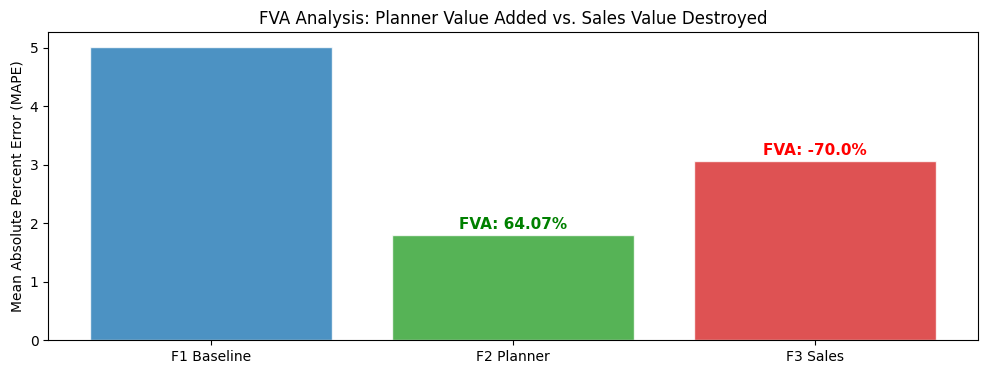

In [7]:
# Data from previous calculation steps
error_labels = ['F1 Baseline', 'F2 Planner', 'F3 Sales']
errors = [5.01, 1.80, 3.06] # MAPEs
fva_planner = 64.07
fva_sales = -70.00
fva_overall = 38.92

df_plot_fva = pd.DataFrame({'Step': error_labels, 'MAPE': errors})

fig, ax = plt.subplots(figsize=(12, 4))
sns.set_style("whitegrid")

bar_colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green (for Planner), Red (for Sales destruction)
bars = ax.bar(df_plot_fva.index, df_plot_fva['MAPE'], color=bar_colors, alpha=0.8)

# Add the FVA percentage text to the chart
fva_results_for_plot = [0, fva_planner, fva_sales] 
for i, fva in enumerate(fva_results_for_plot):
    if i > 0:
        # Determine color for text based on FVA sign
        text_color = 'green' if fva > 0 else 'red'
        ax.text(i, df_plot_fva.iloc[i]['MAPE'] + 0.1, 
                f"FVA: {fva}%", 
                ha='center', fontsize=11, color=text_color, weight='bold')

ax.set_xticks(df_plot_fva.index)
ax.set_xticklabels(df_plot_fva['Step'], rotation=0)
ax.set_ylabel('Mean Absolute Percent Error (MAPE)')
ax.set_title(f'FVA Analysis: Planner Value Added vs. Sales Value Destroyed')
plt.show()

### Evaluating Functional FVA Contribution:

The FVA results provide clear evidence regarding the value of each intervention:

* **Planner Adjustment**: The Demand Planner's deep knowledge of the business and the forecast tool (baseline) was decisive to correct the initial error by over 64%. They received the Automatic model's forecast, with 5% of error, and adjusted the forecast only in the critical months achieving a very low final MAPE.

*  **Sales Adjustment**: The Sales adjustment made the forecast 70% worse. They introduced a strong bias that moved the forecast away from actual demand.

**Key Takeaway**: This analysis demonstrates that the Demand Planning function is the primary driver of value in the process, serving as the necessary check against systematic error. The Sales override failed to add value lowering the accuracy gained by the Planner, ultimately compromising the quality of the final forecast.

### Leveraging FVA: Adjusting Influence in the S&OP Process (Consensus Focus)

The FVA results provide the data needed to govern the collaborative S&OP process, ensuring that human intervention is focused and value-driven. While the analysis showed the Demand Planner (F2) is the most reliable forecast contributor, the sales team's qualitative knowledge remains crucial. The strategy is to formalize the flow of information and forecast adjustments.

* The Planner Adjusted Forecast (F2) must be established as the "Recommended Consensus Start" for the S&OP meeting. Since the planner delivered a FVA of +64.07%, any subsequent adjustment must start from this version.

* During the consensus meeting, any further adjustment must take into consideration the FVA weights achieved. In some case the authority to adjust the final plan can be temporarely restricted.

* Qualitative Inputs that comes from all over the organization are always important for the planning process. In this scenario, these input  should be captured and delivered to the Demand Planner before the S&OP meeting. The Planner will then review use them to adjust the automatic model (F1) to create a stronger (F2). This ensures Sales input is considered by the planning expert before consensus.

* The negative Sales FVA must trigger mandatory training on forecast methodology for the Sales team to eliminate behavioral bias and improve the quality of their qualitative input for the next cycle.

* The final consensus meeting should not be a negotiation of numbers, but a risk assessment against the (F2) baseline. All teams (Demand Planning, Sales, Finance, Operations) collectively agree on the single, common, and unconstrained demand plan. The discussion focuses only on:

  -1. Validating the F2 assumptions.

  
  -2. Making minor adjustments where new information has emerged since F2 was finalized.


By implementing this structure, the process retains the benefits of collaborative input while using FVA to ensure that only value-adding steps influence the final decision.

### Alternative Approach: Ensemble Method

As an alternative, organizations can use FVA results to implement a numerical weighting system (an ensemble forecast). This approach automates the final forecast by blending the output of all individual forecasts, giving greater weight to the most historically accurate contributor.

In this model, the final Consensus Forecast is a weighted average of all independent forecasts. Weights are calculated inversely proportional to the historical error. in this example:

* F1 (Automatic Model)  = 1/5.01 ≈ 0.20   --> Normalized Weight = 18.5%
* F2 (Planner Adjusted) = 1/1.80 ≈ 0.55   --> Normalized Weight = 51.0%
* F3 (Sales Adjusted)   = 1/3.06 ≈ 0.33   --> Normalized Weight = 30.5%

The resulting ensemble forecast would mathematically assign half of the final influence to the Planner Adjusted Forecast, while significantly reducing the influence of the underperforming Sales Forecast. This method ensures that historical error directly controls future forecast.

# What is Allocation Value Added (AVA)?

Allocation Value Added (AVA) is a method that **extends the FVA principle to the execution phase** of the supply chain. AVA measures whether a human planner's adjustments to a system-generated allocation proposal actually improve the final distribution outcome in terms of real costs (e.g., minimizing stockouts and overstocks).

### Why AVA Matters to Supply Chain Professionals?

Just as with forecasting, system-recommended allocations are often manually adjusted. These adjustments can be based on feelings, incomplete local information, or even internal politics. the objective of AVA is to:

* Quantify Planner Impact: Measure the financial value added (or destroyed) by allocation planners.

* Optimize Inventory Flow: Ensure stock is placed where it generates the most profit and minimizes penalties.

* Validate System Rules: Confirm if the automated allocation system is performing optimally, or if planner input reveals recurrent system's errors.

### Measuring Error in Distribution:

In distribution, a simple percentage error (like MAPE) is not enough. The cost of a stockout is usually greater than the cost of an equivalent overstock. Therefore, AVA uses a cost-based performance metric to measure the errors.
The Error for AVA is the **Total Allocation Penalty**, which is the sum of quantified financial losses from stockouts and overstock for a given allocation decision.

The AVA formula then becomes:

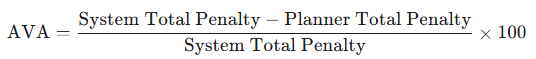
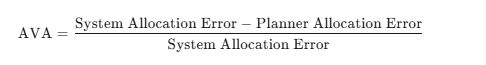
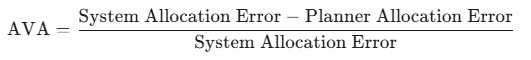

### Scenario:

We examine **three weekly allocation decisions for a single product**. This setup demonstrates the critical trade-off: the significant gains from a correct intervention (Run 1) versus the destruction from unnecessary or biased interventions (Runs 2 & 3).

The automated system proposes an allocation. The planner, possessing local knowledge adjusts the allocation. We will determine if this adjustment reduced the total financial penalty.

**Assumptions**:

* Lost Profit per Stockout Unit = €10

* Holding Cost per Excess Unit = €2

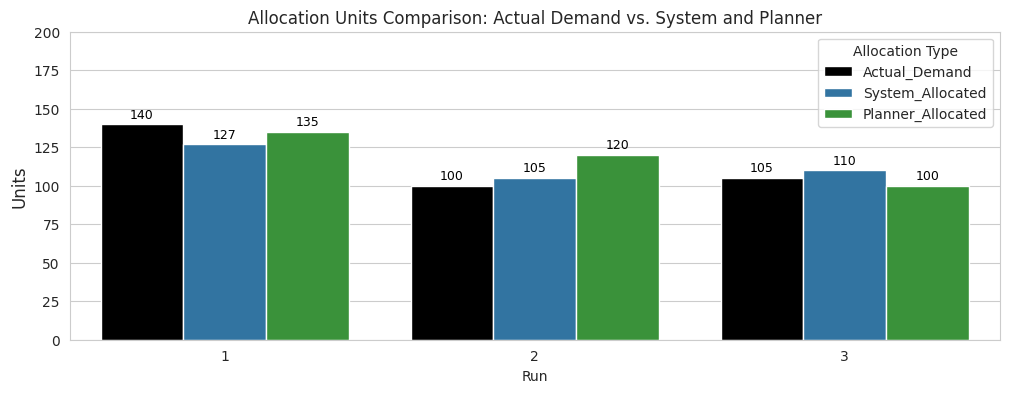

In [8]:
# AVA Multi-Run
ava_data_multi = {
    'Run': [1, 2, 3],
    'Actual_Demand': [140, 100, 105],
    'System_Allocated': [127, 105, 110],
    'Planner_Allocated': [135, 120, 100]}
df_ava_multi = pd.DataFrame(ava_data_multi)

# Melt the dataframe for Seaborn grouped bar plot
df_units_melt = df_ava_multi.melt(
    id_vars='Run', 
    value_vars=['Actual_Demand', 'System_Allocated', 'Planner_Allocated'], 
    var_name='Metric', 
    value_name='Units')

fig, ax = plt.subplots(figsize=(12, 4))
sns.set_style("whitegrid")


palette = {
    'Actual_Demand': 'black',
    'System_Allocated': '#1f77b4',
    'Planner_Allocated': '#2ca02c'}

sns.barplot(
    x='Run', 
    y='Units', 
    hue='Metric', 
    data=df_units_melt, 
    palette=palette, 
    ax=ax)

for p in ax.patches:
    # Get height of the bar (the unit value)
    height = p.get_height()
    # Annotate the value on top of the bar
    ax.annotate(f"{height:.0f}", 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', 
                fontsize=9,
                color='black',
                xytext=(0, 7), # 7 points vertical offset
                textcoords='offset points')


ax.set_ylabel('Units', fontsize=12)
ax.set_title('Allocation Units Comparison: Actual Demand vs. System and Planner')
ax.legend(title='Allocation Type')
ax.set_ylim([0, 200])

plt.show()

The code below computes the total run penalties and the global penalties for both System and Planner. Using this metrics we will be able to calculate the AVA for the single run but also the global AVA.

In [9]:
LOST_PROFIT_PER_UNIT = 10
HOLDING_COST_PER_UNIT = 2

def calculate_penalties(df, allocated_col):
    """Calculates Stockout and Excess Penalties for a given allocation column."""
    # Stockout occurs when Actual Demand > Allocated
    stockout = df.apply(lambda row: max(0, row['Actual_Demand'] - row[allocated_col]), axis=1)
    # Excess occurs when Allocated > Actual Demand
    excess = df.apply(lambda row: max(0, row[allocated_col] - row['Actual_Demand']), axis=1)
    
    stockout_penalty = stockout * LOST_PROFIT_PER_UNIT
    excess_penalty = excess * HOLDING_COST_PER_UNIT
    
    return stockout_penalty + excess_penalty

# Calculate Total Penalty for System and Planner
df_ava_multi['System_Penalty'] = calculate_penalties(df_ava_multi, 'System_Allocated')
df_ava_multi['Planner_Penalty'] = calculate_penalties(df_ava_multi, 'Planner_Allocated')

# Total Penalties Across All Runs
total_system_penalty = df_ava_multi['System_Penalty'].sum()
total_planner_penalty = df_ava_multi['Planner_Penalty'].sum()

# Calculate Overall AVA
ava_overall_multi = round((total_system_penalty - total_planner_penalty) / total_system_penalty * 100, 2)

# Calculate individual run AVA for reporting
def calculate_run_ava(system_penalty, planner_penalty):
    if system_penalty == 0:
        # If system is perfect (Penalty $0), any planner error is destruction
        return 100 if planner_penalty == 0 else round((0 - planner_penalty) / 0.001 * 100, 2) # Arbitrarily high negative for destruction from 0
    return round((system_penalty - planner_penalty) / system_penalty * 100, 2)

df_ava_multi['Run_AVA'] = df_ava_multi.apply(
    lambda row: calculate_run_ava(row['System_Penalty'], row['Planner_Penalty']), 
    axis=1
)

### Analysis of Individual and Total AVA:

* **Run1:** Actual demand was 140 units, while the system proposed 127 units. The Planner, correctly identifying an un-tracked market event, allocated 135 units, saving 80€ in lost profit. The system's total penalty was 130€ (due to 13 units of stockout). The Planner's allocation generated only a 50€ profit loss.

* **Run2:** Planner costs the company 30€ by creating unnecessary overstock. Actual demand was 100 units, system proposal was 105 units, planner's adjustment was 120 units.

* **Run3:** Planner increases the penalty by turning a minor overstock into an expensive stockout. Actual Demand was 105 units, System Proposed 110 (10€ overstock cost), Planner's allocation was 100 units, resulting in a 50€ profit loss due to stockout.

### Total Evaluation: The Risk of Unjustified Overwrite

**The overall AVA is positive by only +7%**, Total System Penalty is 150€ while Total Planner's penalty is 140€, but this value is entirely driven by the single intervention in Run 1. This gain barely compensates for the significant losses incurred by the poor and unjustified interventions in Runs 2 and 3.

**Conclusion**: The analysis clearly shows that the Planner must overwrite the system only when they are certain of a local event not captured by the system (like the promotion in Run 1). The risk of generating a much bigger financial error when intervening without concrete evidence is high and unnecessary.

The Planner's override authority should therefore be restricted to only those situations where they possess **concrete and documented knowledge**. Any planner adjustment that creates a stockout where the system predicted a surplus (as seen in Run 3) should trigger a high-risk review before execution. As this example demonstrates, frequent adjustments made purely by "gut feeling" can lead to much bigger errors in the long run. However, the overall planning process must continue integrating the Planner's well-documented knowledge about local events for continuous improvement.

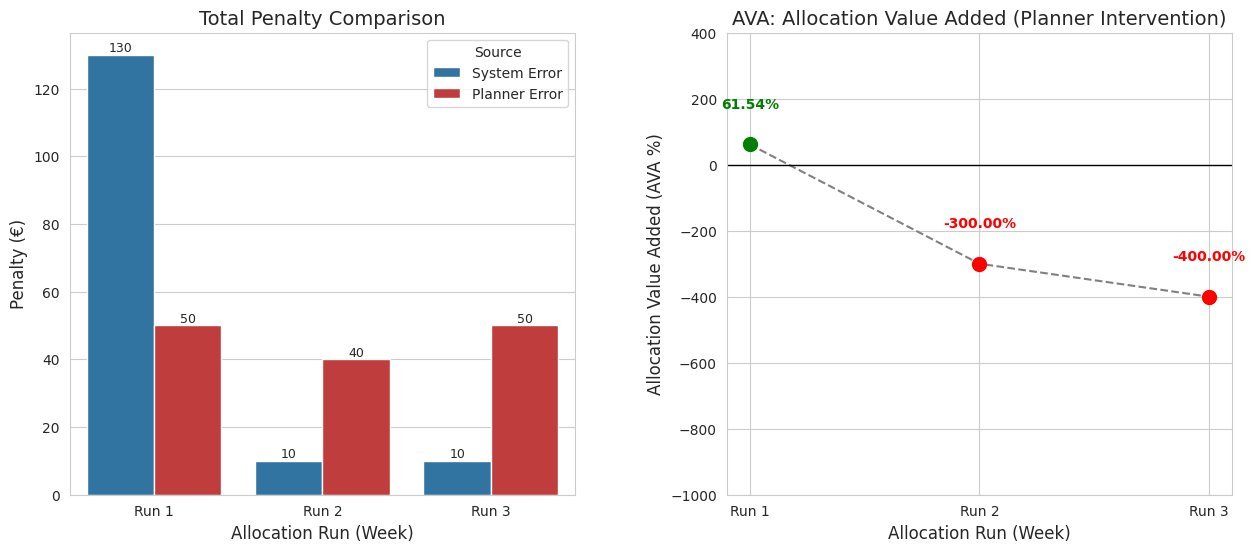

In [10]:
df_errors = df_ava_multi[['Run', 'System_Penalty', 'Planner_Penalty']].melt(
    id_vars='Run',
    var_name='Error_Source',
    value_name='Unit_Error'
)
df_errors['Error_Source'] = df_errors['Error_Source'].replace({
    'System_Penalty': 'System Error',
    'Planner_Penalty': 'Planner Error'
})

df_errors['Run'] = df_errors['Run'].astype(str)


fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(15, 6))
plt.subplots_adjust(wspace=0.3)
sns.set_style("whitegrid")


# Line Plot for AVA
sns.lineplot(
    x='Run', 
    y='Run_AVA', 
    data=df_ava_multi, 
    marker='o', 
    markersize=10,
    linestyle='--',
    color='gray', 
    ax=ax1
)

for index, row in df_ava_multi.iterrows():
    color = 'green' if row['Run_AVA'] > 0 else 'red'
    # Plot the scatter point using the specific color
    ax1.scatter(row['Run'], row['Run_AVA'], color=color, s=100, zorder=3)
    
    ax1.text(row['Run'], row['Run_AVA'] + 100, 
             f"{row['Run_AVA']:.2f}%", 
             ha='center', va='bottom', fontsize=10, weight='bold', color=color)

ax1.axhline(0, color='black', linestyle='-', linewidth=1)
ax1.set_title('AVA: Allocation Value Added (Planner Intervention)', fontsize=14)
ax1.set_xlabel('Allocation Run (Week)', fontsize=12)
ax1.set_ylabel('Allocation Value Added (AVA %)', fontsize=12)
ax1.set_xticks(df_ava_multi['Run'])
ax1.set_xticklabels([f"Run {r}" for r in df_ava_multi['Run']])
ax1.set_ylim([-1000, 400])

# --- RIGHT SUBPLOT (ax2): Unit Error Comparison ---

sns.barplot(
    x='Run', 
    y='Unit_Error', 
    hue='Error_Source', 
    data=df_errors, 
    palette={'System Error': '#1f77b4', 'Planner Error': '#d62728'}, 
    ax=ax2
)

ax2.set_title('Total Penalty Comparison', fontsize=14)
ax2.set_xlabel('Allocation Run (Week)', fontsize=12)
ax2.set_ylabel('Penalty (€)', fontsize=12)
ax2.legend(title='Source')
ax2.set_xticks(df_ava_multi['Run'] - 1)
ax2.set_xticklabels([f"Run {r}" for r in df_ava_multi['Run']])


# Annotate unit error values on bars
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', 
                 xytext=(0, 5), 
                 textcoords='offset points',
                 fontsize=9)

plt.show()

# Conclusion: Continuous Improvement Across the Supply Chain

**Forecast Value Added (FVA)** and **Allocation Value Added (AVA)** are indispensable tools for modern supply chain professionals,providing financial quantification of human intervention.

* FVA guides improvements in the planning process, ensuring that S&OP discussions are data-driven and that forecasting efforts are concentrated where they truly reduce demand error.

* AVA provides crucial insights into the execution process, validating planner decisions and highlighting areas where automated allocation rules might need enhancement or where planners possess unique information.

By integrating both FVA and AVA into regular performance reviews and continuous improvement initiatives, organizations can systematically identify waste, empower high-value contributors, and achieve financial benefits throughout their supply chain. **These metrics transform subjective judgments into objective insights, fostering a culture of data-driven decision-making**.